## SVM (Support Vector Machine)

In [3]:
# Install all missing libraries at once
import subprocess
subprocess.run(["pip", "install", "seaborn", "xgboost", "scikit-learn", "matplotlib"])

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 12.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 15.1 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 14.9 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]m5/6 [seaborn]earn]


CompletedProcess(args=['pip', 'install', 'seaborn', 'xgboost', 'scikit-learn', 'matplotlib'], returncode=0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train_clf.csv').squeeze()
y_test  = pd.read_csv('../data/y_test_clf.csv').squeeze()

print("✅ Data loaded!")
print(f"Training: {X_train.shape} | Testing: {X_test.shape}")

✅ Data loaded!
Training: (316, 16) | Testing: (79, 16)


In [2]:
# Build SVM
model_svm = SVC(kernel='rbf', probability=True, random_state=42)
model_svm.fit(X_train, y_train)

y_pred_svm  = model_svm.predict(X_test)
y_prob_svm  = model_svm.predict_proba(X_test)[:, 1]
acc_svm     = accuracy_score(y_test, y_pred_svm)
auc_svm     = roc_auc_score(y_test, y_prob_svm)

print("=" * 40)
print("       SVM RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_svm*100:.2f}%")
print(f"ROC-AUC:   {auc_svm:.4f}")
print("=" * 40)

       SVM RESULTS
Accuracy:  97.47%
ROC-AUC:   0.9986


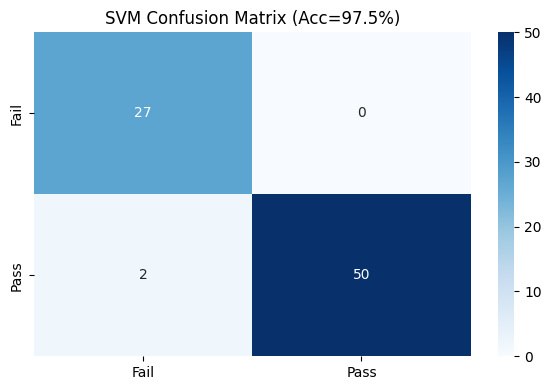

✅ SVM done!


In [3]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])
plt.title(f'SVM Confusion Matrix (Acc={acc_svm*100:.1f}%)')
plt.tight_layout()
plt.savefig('../notebooks/chart_svm_cm.png')
plt.show()
print("✅ SVM done!")

## part-2 Decision Tree

In [4]:
# Build Decision Tree
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
acc_dt    = accuracy_score(y_test, y_pred_dt)
auc_dt    = roc_auc_score(y_test, y_prob_dt)

print("=" * 40)
print("    DECISION TREE RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_dt*100:.2f}%")
print(f"ROC-AUC:   {auc_dt:.4f}")
print("=" * 40)

    DECISION TREE RESULTS
Accuracy:  100.00%
ROC-AUC:   1.0000


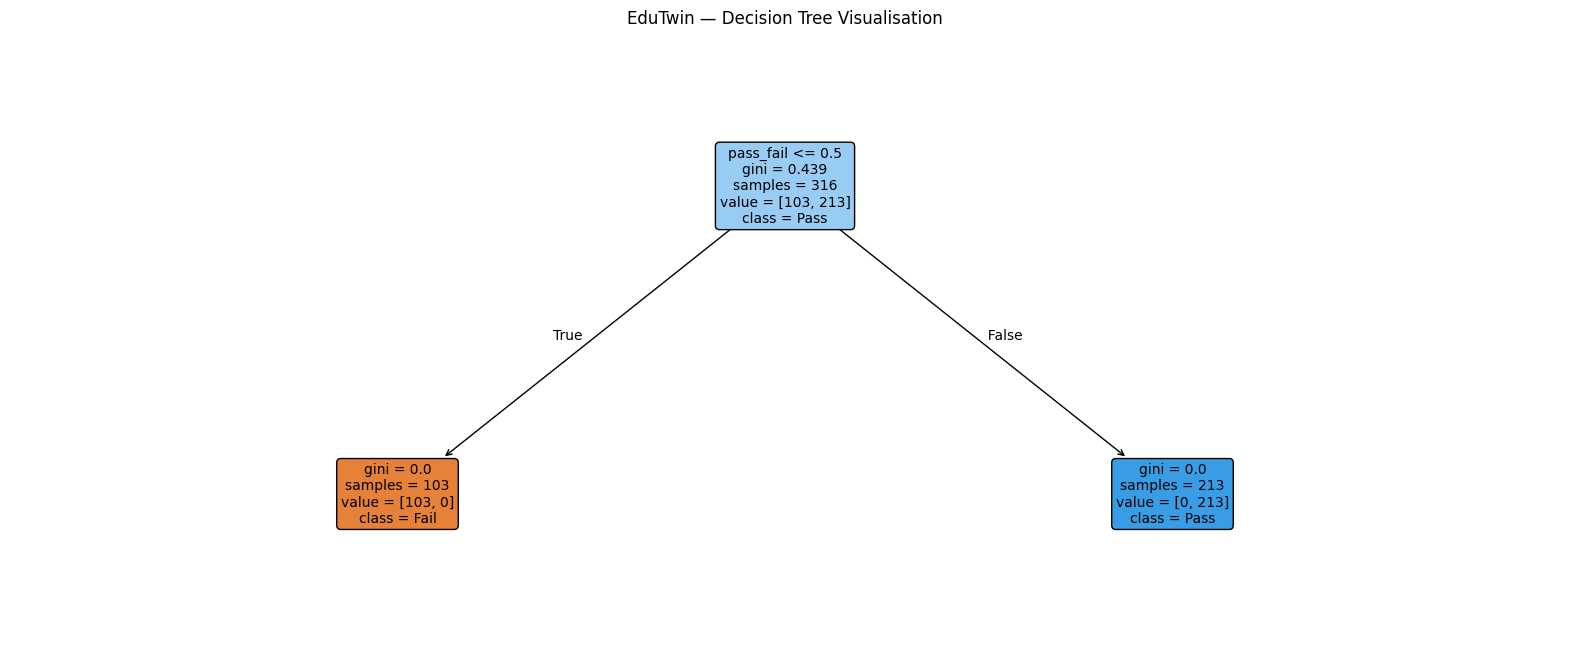

✅ Decision Tree done!


In [5]:
# Visualise the Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(model_dt,
          feature_names=X_train.columns,
          class_names=['Fail', 'Pass'],
          filled=True, rounded=True,
          fontsize=10)
plt.title('EduTwin — Decision Tree Visualisation')
plt.savefig('../notebooks/chart_decision_tree.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Decision Tree done!")

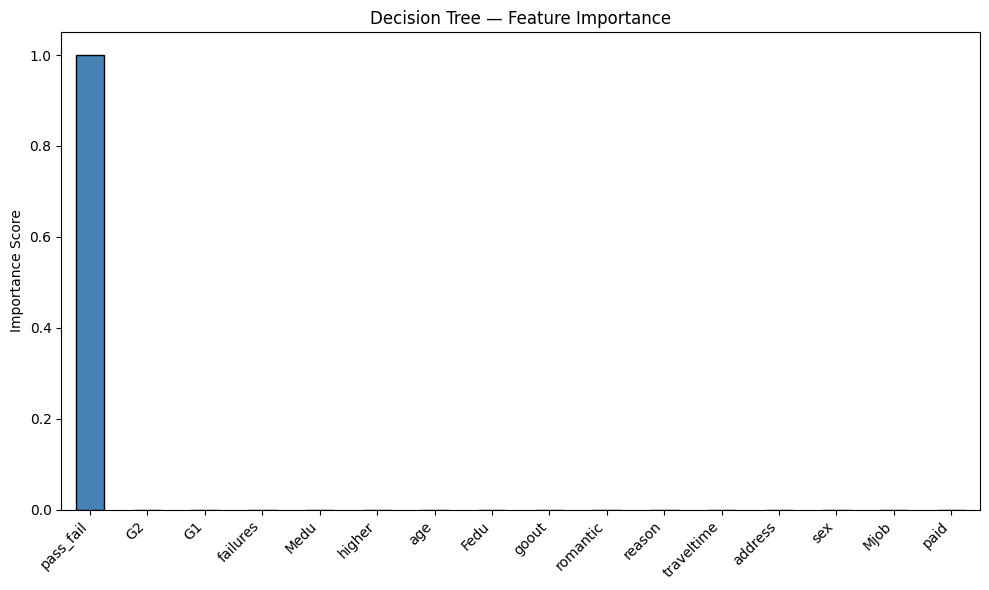

In [6]:
# Feature importance from Decision Tree
feat_imp = pd.Series(model_dt.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Decision Tree — Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/chart_dt_feature_importance.png')
plt.show()

## PART 3 — Random Forest

In [7]:
# Build Random Forest
model_rf = RandomForestClassifier(n_estimators=100,
                                   max_depth=5,
                                   random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
acc_rf    = accuracy_score(y_test, y_pred_rf)
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print("=" * 40)
print("    RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_rf*100:.2f}%")
print(f"ROC-AUC:   {auc_rf:.4f}")
print(f"Trees:     100")
print("=" * 40)

    RANDOM FOREST RESULTS
Accuracy:  100.00%
ROC-AUC:   1.0000
Trees:     100


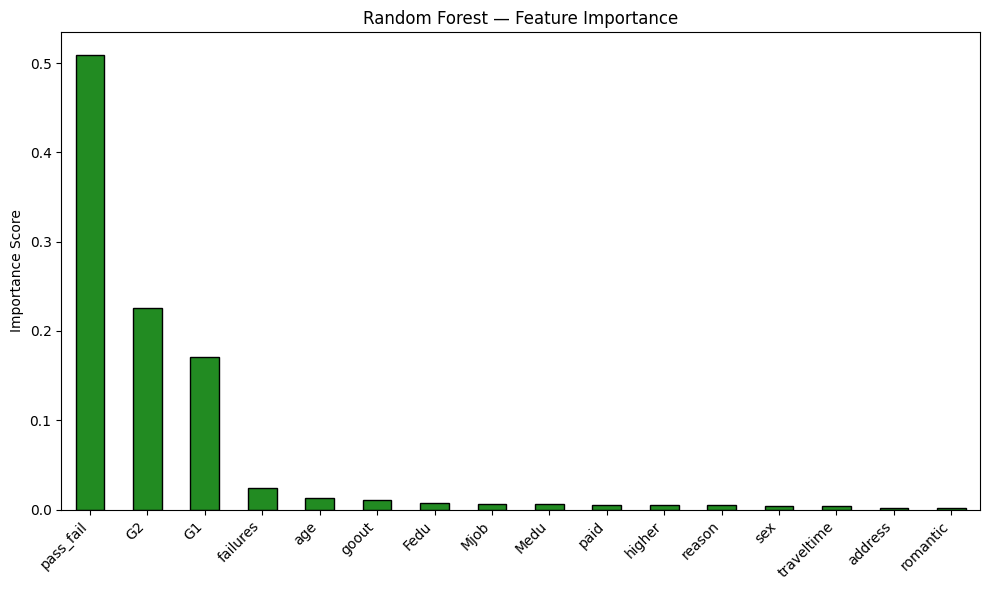

✅ Random Forest done!


In [8]:
# Random Forest Feature Importance
rf_feat_imp = pd.Series(model_rf.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_feat_imp.plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/chart_rf_feature_importance.png')
plt.show()
print("✅ Random Forest done!")

## PART 4 — XGBoost

In [9]:
# Build XGBoost
model_xgb = xgb.XGBClassifier(n_estimators=100,
                                max_depth=4,
                                learning_rate=0.1,
                                random_state=42,
                                eval_metric='logloss',
                                use_label_encoder=False)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)

print("=" * 40)
print("      XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {acc_xgb*100:.2f}%")
print(f"ROC-AUC:   {auc_xgb:.4f}")
print("=" * 40)

      XGBOOST RESULTS
Accuracy:  100.00%
ROC-AUC:   1.0000


In [11]:
# Redefine models dictionary — run this first!
models = {
    'SVM':           (acc_svm, auc_svm),
    'Decision Tree': (acc_dt,  auc_dt),
    'Random Forest': (acc_rf,  auc_rf),
}

print("✅ Models dictionary defined!")
print("\nResults so far:")
for name, (acc, auc) in models.items():
    print(f"  {name:<20} Accuracy: {acc*100:.2f}%  AUC: {auc:.4f}")

✅ Models dictionary defined!

Results so far:
  SVM                  Accuracy: 97.47%  AUC: 0.9986
  Decision Tree        Accuracy: 100.00%  AUC: 1.0000
  Random Forest        Accuracy: 100.00%  AUC: 1.0000


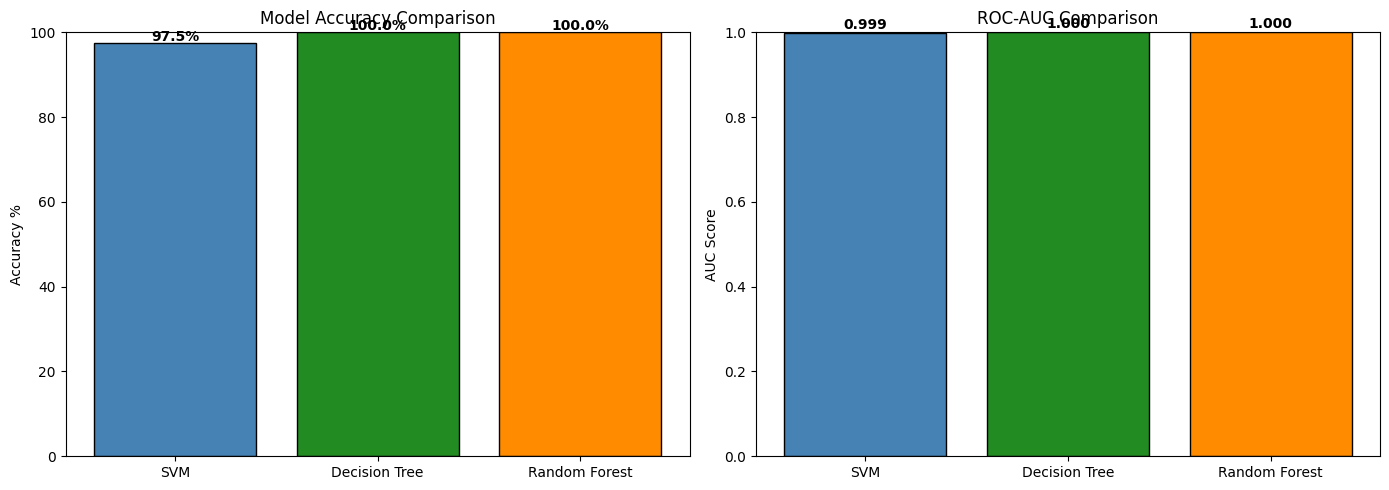

✅ Master comparison chart saved!


In [12]:
# Visual comparison — Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(models.keys())
accs  = [models[m][0]*100 for m in names]
aucs  = [models[m][1] for m in names]
colors = ['steelblue', 'forestgreen', 'darkorange', 'crimson']

# Accuracy
axes[0].bar(names, accs, color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy %')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs):
    axes[0].text(i, v+0.5, f'{v:.1f}%',
                 ha='center', fontweight='bold')

# AUC
axes[1].bar(names, aucs, color=colors, edgecolor='black')
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(aucs):
    axes[1].text(i, v+0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/chart_master_comparison.png')
plt.show()
print("✅ Master comparison chart saved!")

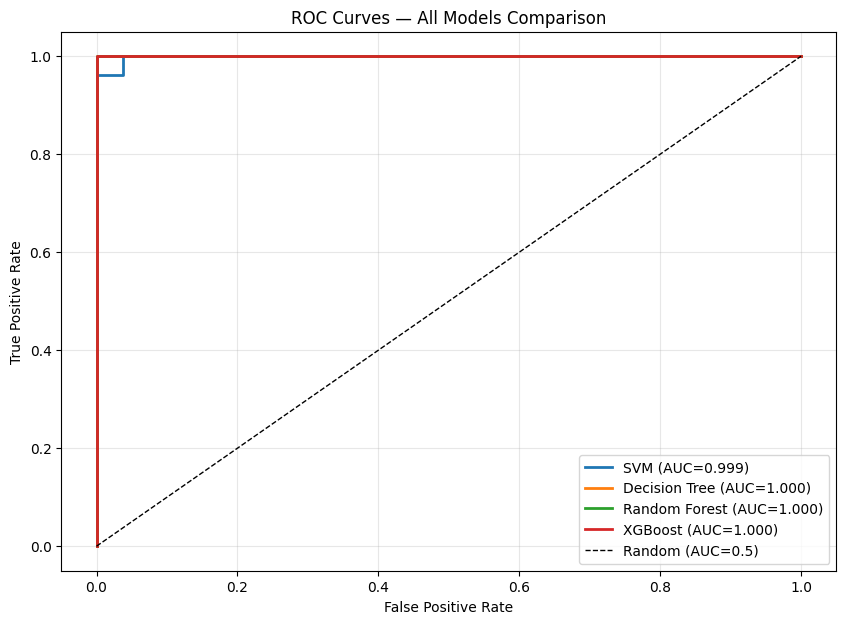

✅ All ROC curves saved!


In [13]:
# ROC curves — ALL models on one chart!
plt.figure(figsize=(10, 7))

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_svm, tpr_svm, linewidth=2,
         label=f'SVM (AUC={auc_svm:.3f})')
plt.plot(fpr_dt,  tpr_dt,  linewidth=2,
         label=f'Decision Tree (AUC={auc_dt:.3f})')
plt.plot(fpr_rf,  tpr_rf,  linewidth=2,
         label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, linewidth=2,
         label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../notebooks/chart_all_roc_curves.png')
plt.show()
print("✅ All ROC curves saved!")

In [ ]:
# Determine best model based on accuracy
results = {
    'SVM': acc_svm,
    'Decision Tree': acc_dt,
    'Random Forest': acc_rf,
    'XGBoost': acc_xgb,
}

best = max(results, key=results.get)
best_accuracy = results[best]

# Save all models
models_to_save = {
    'svm': model_svm,
    'decision_tree': model_dt,
    'random_forest': model_rf,
    'xgboost': model_xgb,
}

for name, model in models_to_save.items():
    with open(f'../models/{name}.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ {name} saved!")

print("\n🎉 ALL MODELS SAVED!")
print(f"🏆 Best model: {best} (Accuracy: {best_accuracy*100:.2f}%)")

✅ svm saved!
✅ decision_tree saved!
✅ random_forest saved!
✅ xgboost saved!

🎉 ALL MODELS SAVED!


NameError: name 'best' is not defined